<a href="https://colab.research.google.com/github/ghanshyamverma4654/Mission-Data-Science/blob/master-branch/IPL_Analysis_MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#Importing essential libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cufflinks as cf
from plotly.offline import iplot

In [7]:
#Importing library that will ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [8]:
#Loading IPL dataset
data = pd.read_csv('IPL.csv')

In [9]:
data.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

**Checking the size of rows and columns of the dataset**

In [11]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns in the IPL dataset.")

There are 74 rows and 20 columns in the IPL dataset.


**How many columns have null values in total**

In [12]:
data.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


**Which team has won the most matches?**

In [13]:
most_match_wins = data['match_winner'].value_counts()

Text(0, 0.5, 'Teams')

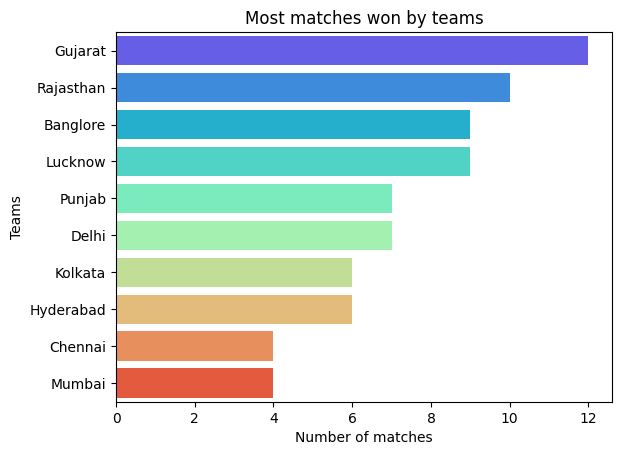

In [14]:
sns.barplot(y = most_match_wins.index, x = most_match_wins.values, palette='rainbow')
plt.title('Most matches won by teams')
plt.xlabel('Number of matches')
plt.ylabel('Teams')

**Toss decision trends**

<Axes: xlabel='toss_decision', ylabel='count'>

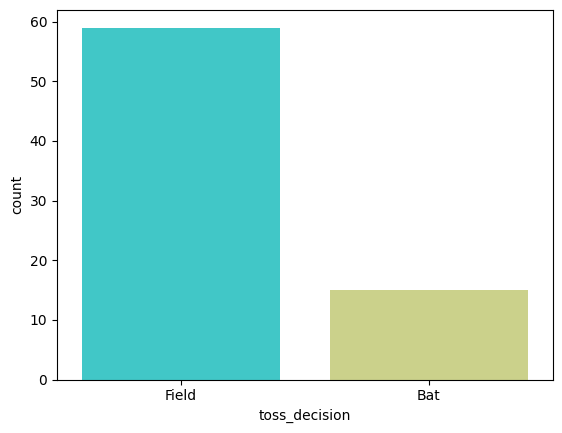

In [15]:
#Means which option most teams choose after winning toss
sns.countplot(x=data['toss_decision'],palette='rainbow')

**Toss winner vs match winner**

In [16]:
#There were 74 matches in this IPL
count = data[data['toss_winner'] == data['match_winner']]['match_id'].count()
count#36
percentage =(count*100)/data.shape[0]
percentage.round(2)#48.65 is the success rate of toss winners

np.float64(48.65)

**How do teams win?(Run vs Wickets)**

<Axes: xlabel='won_by', ylabel='count'>

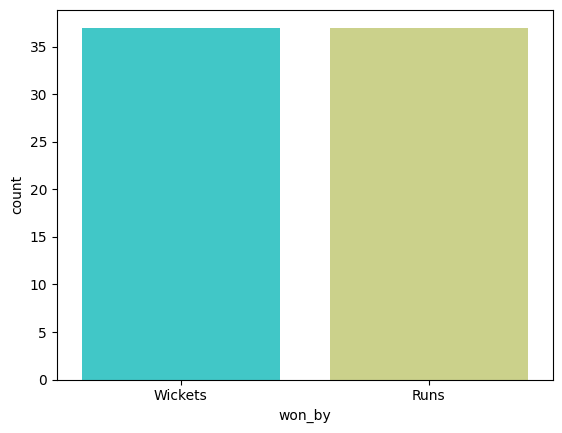

In [17]:
sns.countplot(x=data['won_by'], palette='rainbow')

**Most "Player of the match" awards**

Text(0, 0.5, 'Player')

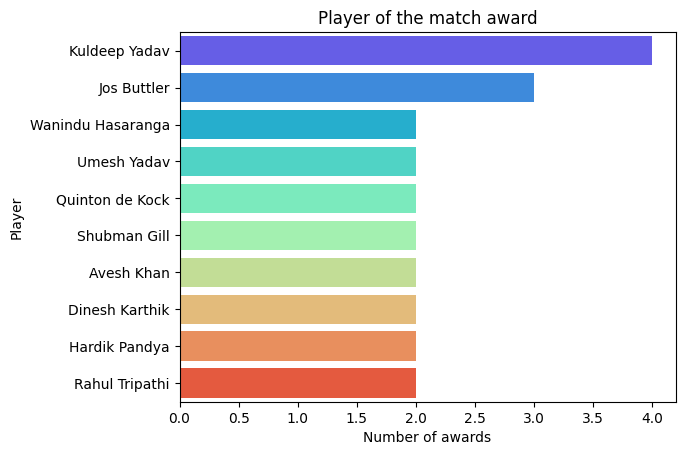

In [18]:
count = data['player_of_the_match'].value_counts().head(10)
sns.barplot(x = count.values, y = count.index, palette = 'rainbow')
plt.title('Player of the match award')
plt.xlabel('Number of awards')
plt.ylabel('Player')

**Top 5 scorers**

In [25]:
topScorer = data.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(5)
#topScorer

Text(0, 0.5, 'Player')

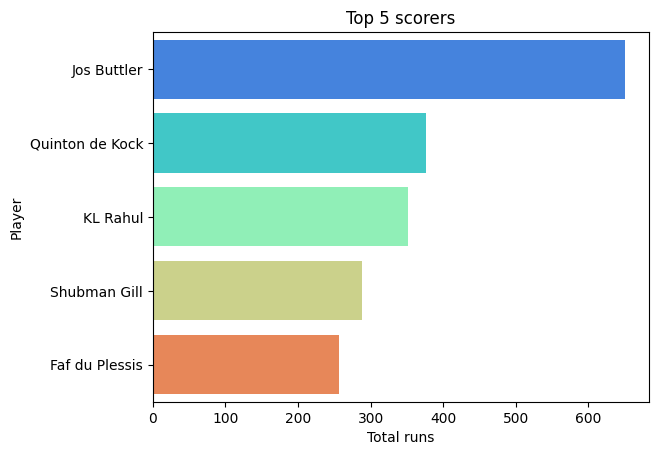

In [67]:
sns.barplot(x = topScorer.values, y = topScorer.index, palette = 'rainbow')
plt.title('Top 5 scorers')
plt.xlabel('Total runs')
plt.ylabel('Player')

**10 best bowlling figures**

In [22]:
data["wickets"] = data['best_bowling_figure'].apply(lambda x: x.split('--')[0])
data['wickets'] = data['wickets'].astype(int)

In [23]:
bestBowlingFigures = data.groupby('best_bowling')['wickets'].sum().sort_values(ascending=False).head(10)

Text(0, 0.5, 'Bowler')

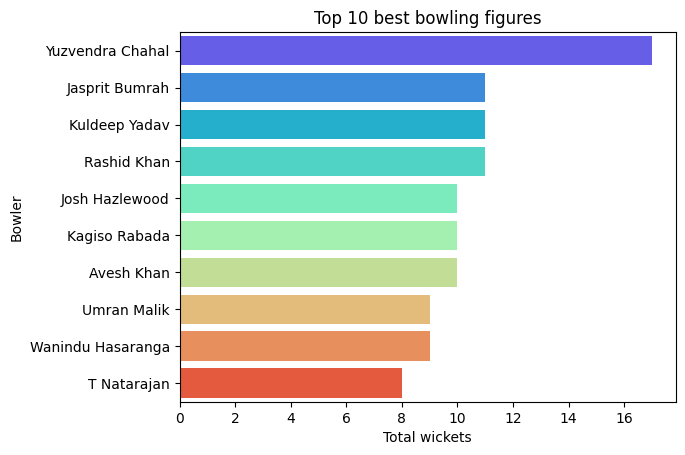

In [24]:
sns.barplot(x = bestBowlingFigures.values, y = bestBowlingFigures.index, palette = 'rainbow')
plt.title('Top 10 best bowling figures')
plt.xlabel('Total wickets')
plt.ylabel('Bowler')

**Venue Analysis**

Most Match Played by Venue

In [31]:
#data.info()
z = data['venue'].value_counts()
z

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


Text(0, 0.5, 'Venue')

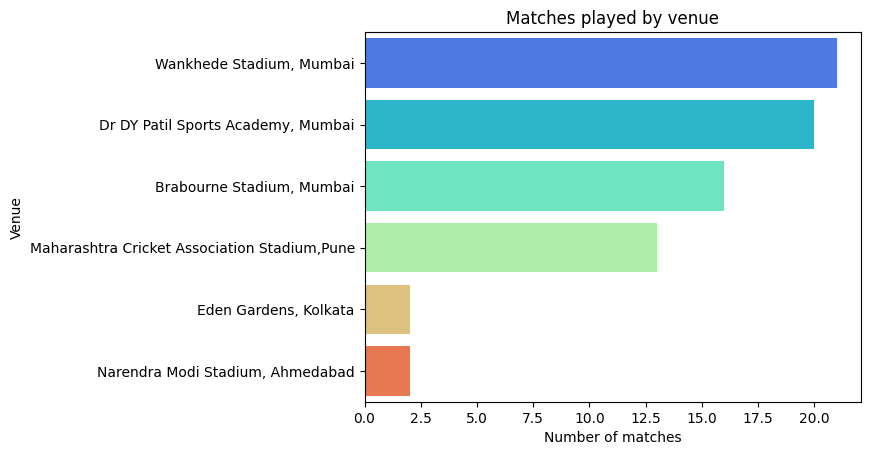

In [33]:
sns.barplot(x=z.values,y=z.index,palette='rainbow')
plt.title('Matches played by venue')
plt.xlabel('Number of matches')
plt.ylabel('Venue')

**Custom questions and Insights**

Who won the highest margin by runs?

Text(0, 0.5, 'Winner')

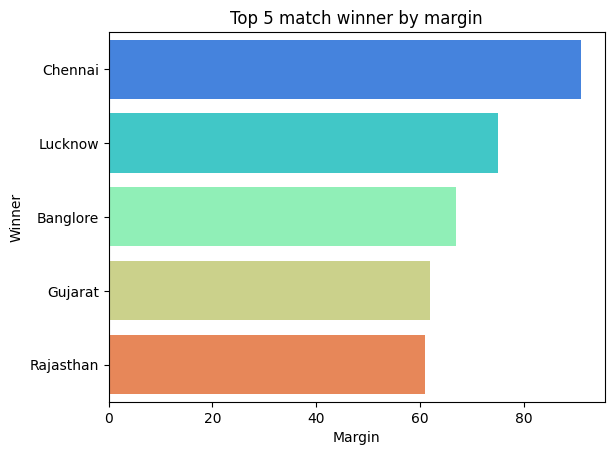

In [42]:
s = data[data['won_by'] == 'Runs'].sort_values(by='margin',ascending=False).head(5)
sns.barplot(x = s['margin'],y=s['match_winner'],palette = 'rainbow')
plt.title('Top 5 match winner by margin')
plt.xlabel('Margin')
plt.ylabel('Winner')

In [36]:
data[data['won_by'] == 'Runs'].sort_values(by = 'margin', ascending = False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Which player had the highest individual score?

In [52]:
g = data.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head(1)
g
#OR | data[data['highscore'] == data['highscore'].max()][['top_scorer','highscore']]

,highscore
top_scorer,
Jos Buttler,651


In [54]:
#Top 10 highscore scorers
top_ten = data.groupby('top_scorer')['highscore'].sum().sort_values(ascending = False).head(10)

Text(0, 0.5, 'Scorers')

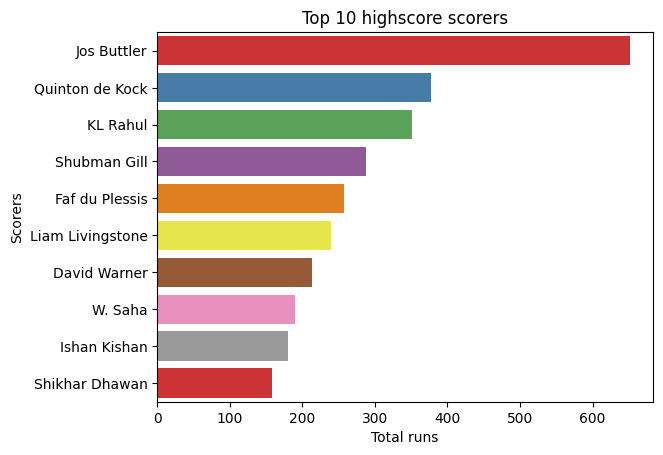

In [60]:
sns.barplot(x = top_ten.values, y = top_ten.index, palette = 'Set1')
plt.title('Top 10 highscore scorers')
plt.xlabel('Total runs')
plt.ylabel('Scorers')

Which bowler had best bowling figure?

In [66]:
j = data[data['wickets'] == data['wickets'].max()][['best_bowling','best_bowling_figure']]
j

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
